## Calculating Codon Adaptation Index

___

In [1]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
import tasep_models as tm
from tasep_models import *

In [2]:
# TASEP models are now imported via pip package in cell 1 above
# (Previously this cell had local path setup code)

In [3]:
one_drive_dir = mi.Utilities.get_one_drive_dir()
# plasmids_path = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/plasmids and primers/Rhiannon\'s plasmids')

# F32 Plasmids Path
plasmids_path = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/Our grants/RMS F32')

In [4]:
HA_TAG = 'YPYDVPDYA'
TAG_list = [HA_TAG]

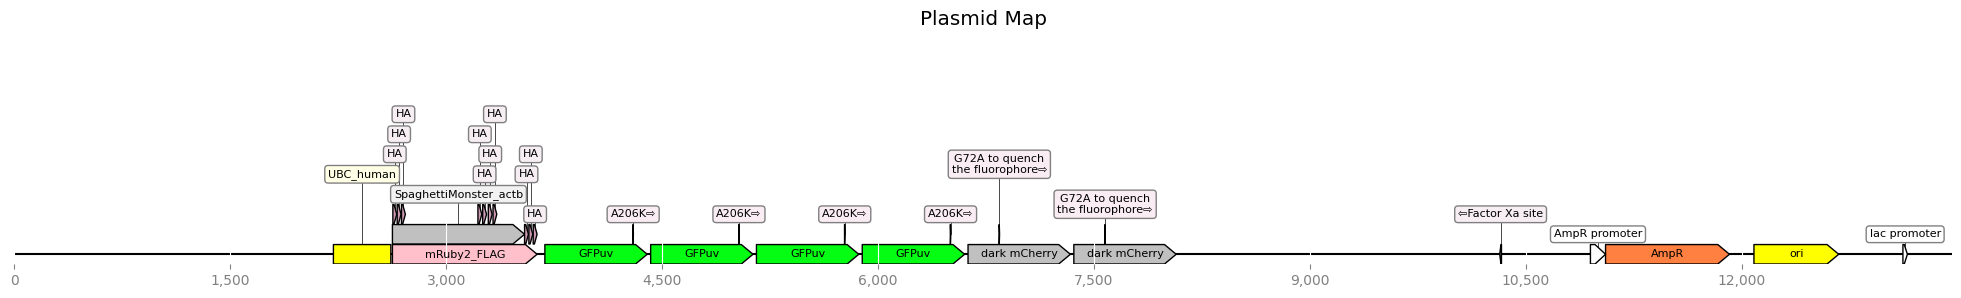

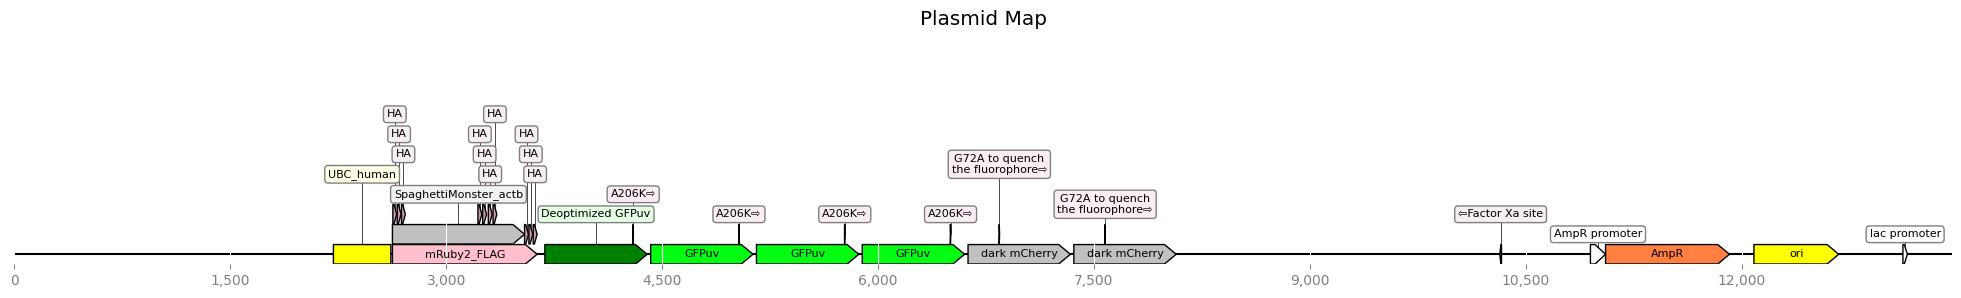

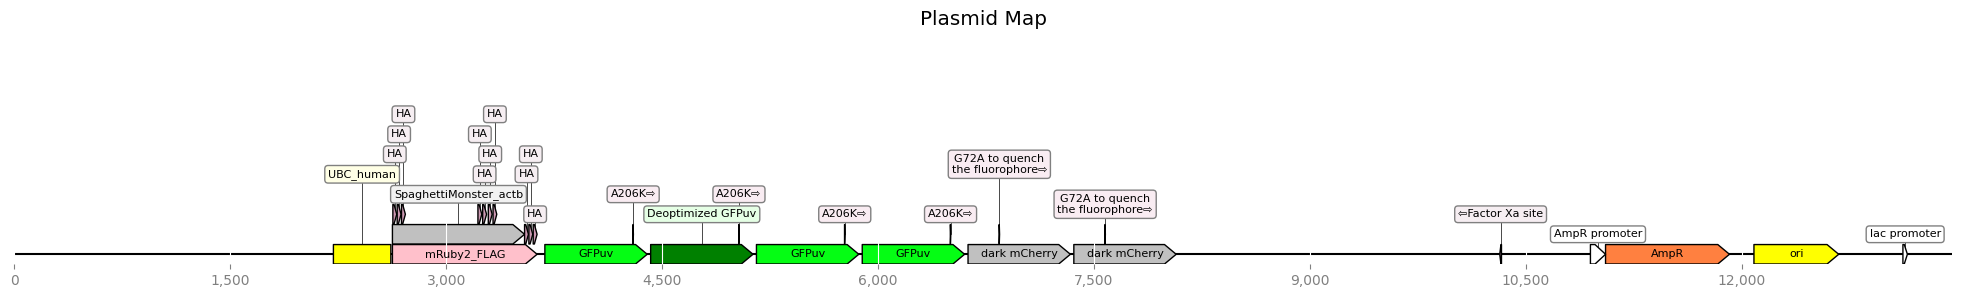

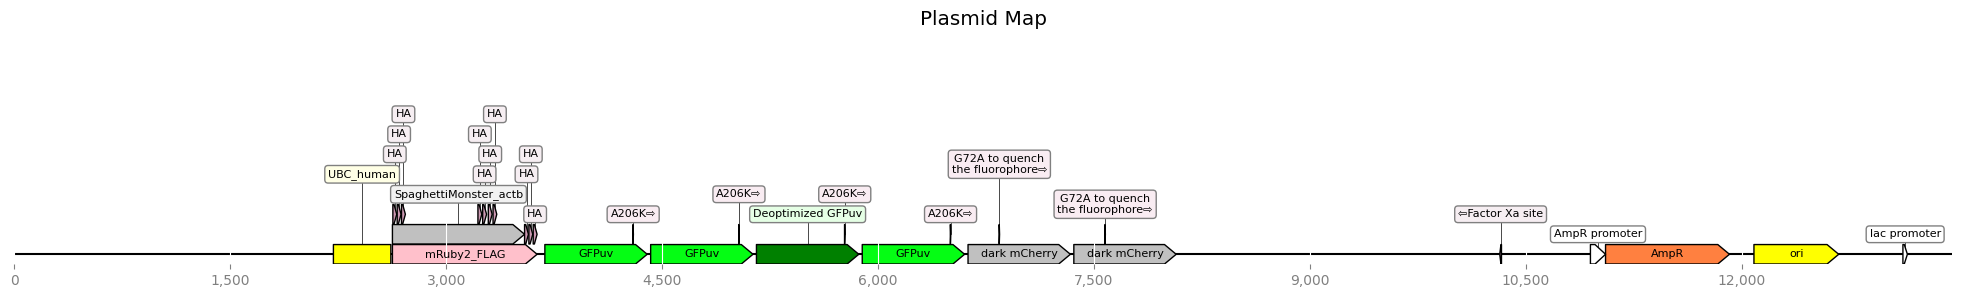

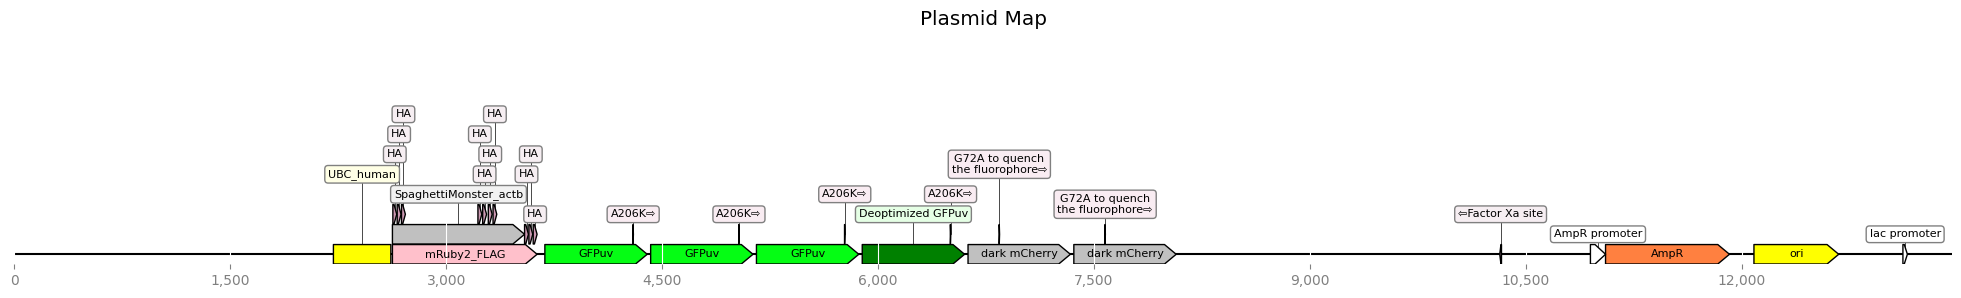

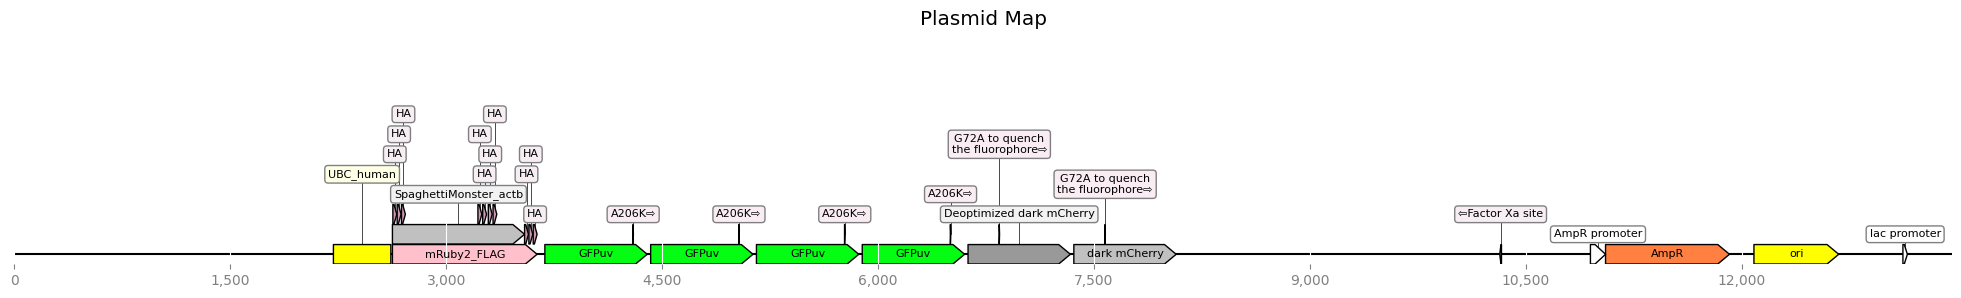

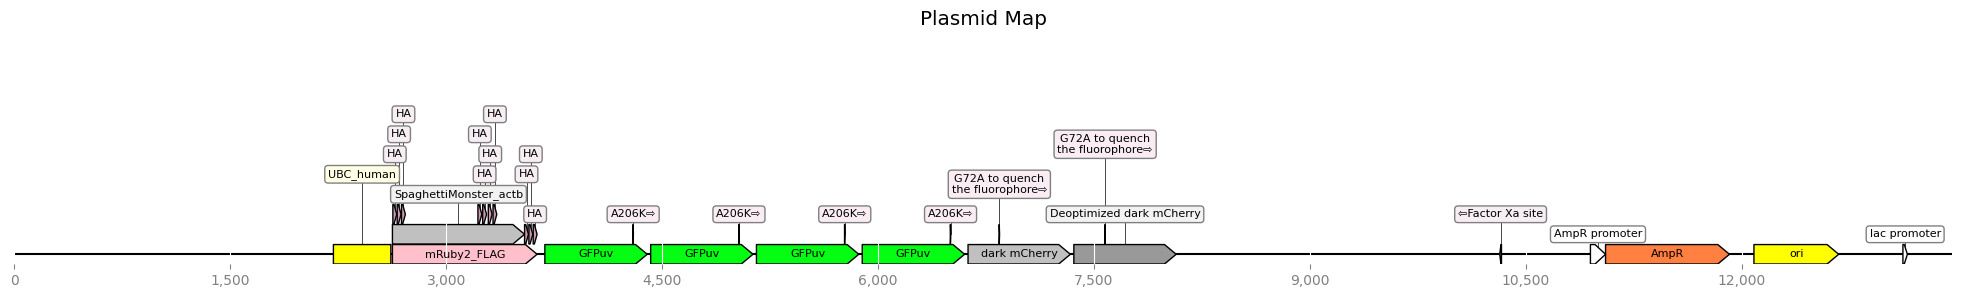

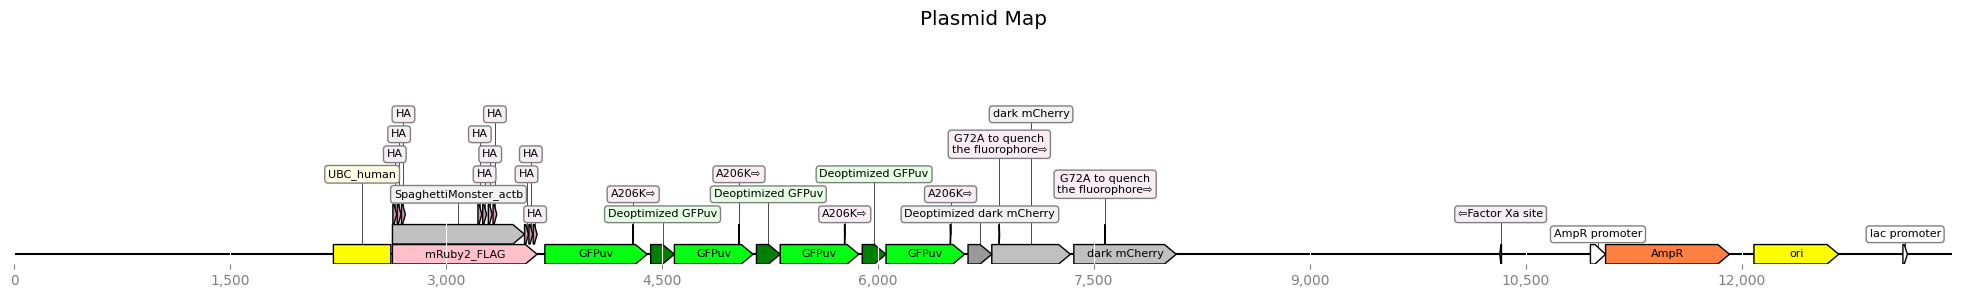

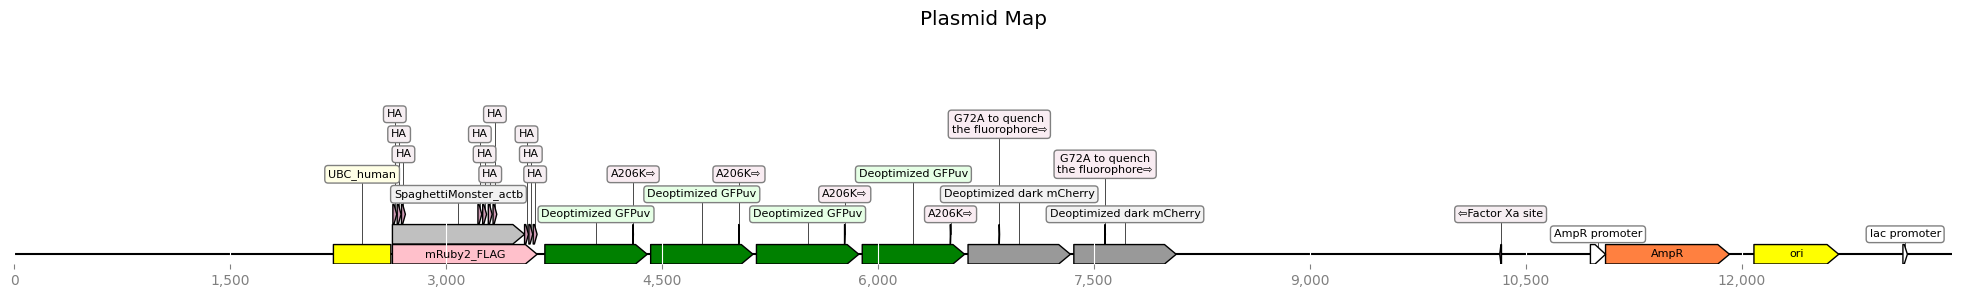

In [5]:
# Load sequences.
gene_sequence_DoReporter1_path =  plasmids_path.joinpath('DoReporter1 (pUB-RBsmHA-4xmGFPuvq-2xmCherryq-24xMS2).dna')
sequence_DoReporter1 = read_gene_sequence(gene_sequence_DoReporter1_path, TAG_list)['rna']

gene_sequence_DoReporter2_path =  plasmids_path.joinpath('DoReporter2 (pUB-RBsmHA-1xDOGFP-3xGFP-2xmCh-24xMS2).dna')
sequence_DoReporter2 = read_gene_sequence(gene_sequence_DoReporter2_path, TAG_list)['rna']

gene_sequence_DoReporter3_path =  plasmids_path.joinpath('DoReporter3 (pUB-RBsmHA-1xGFP-1xDoGFP-2xGFP-2xmCh-24xMS2).dna')
sequence_DoReporter3 = read_gene_sequence(gene_sequence_DoReporter3_path, TAG_list)['rna']

gene_sequence_DoReporter4_path =  plasmids_path.joinpath('DoReporter4 (pUB-RBsmHA-2xGFP-1xDoGFP-1xGFP-2xmCh-24xMS2).dna')
sequence_DoReporter4 = read_gene_sequence(gene_sequence_DoReporter4_path, TAG_list)['rna']

gene_sequence_DoReporter5_path =  plasmids_path.joinpath('DoReporter5 (pUB-RBsmHA-3xGFP-1xDoGFP-2xmCh-24xMS2).dna')
sequence_DoReporter5 = read_gene_sequence(gene_sequence_DoReporter5_path, TAG_list)['rna']

gene_sequence_DoReporter6_path =  plasmids_path.joinpath('DoReporter6 (pUB-RBsmHA-4xGFP-1xDOmCh-1xmCh-24xMS2).dna')
sequence_DoReporter6 = read_gene_sequence(gene_sequence_DoReporter6_path, TAG_list)['rna']

gene_sequence_DoReporter7_path =  plasmids_path.joinpath('DoReporter7 (pUB-RBsmHA-4xGFP-1xmCh-1xDOmCh-24xMS2).dna')
sequence_DoReporter7 = read_gene_sequence(gene_sequence_DoReporter7_path, TAG_list)['rna']

gene_sequence_DoReporter8_path =  plasmids_path.joinpath('DoReporter8 (pUB-RBsmHA-4xGFP-2xmCh-DO-24xMS2).dna')
sequence_DoReporter8 = read_gene_sequence(gene_sequence_DoReporter8_path, TAG_list)['rna']

gene_sequence_DoReporter9_path =  plasmids_path.joinpath('DoReporter9 (pUB-RBsmHA-4xmGFPuvqDO-2xmChqDO-24xMS2).dna')
sequence_DoReporter9 = read_gene_sequence(gene_sequence_DoReporter9_path, TAG_list)['rna']

In [13]:
#list_of_sequences = [sequence_DoReporter1, sequence_DoReporter2, sequence_DoReporter3, sequence_DoReporter4, sequence_DoReporter5, sequence_DoReporter6, sequence_DoReporter7, sequence_DoReporter8]
#list_of_sequences_names = ['DoReporter1', 'DoReporter2', 'DoReporter3', 'DoReporter4', 'DoReporter5', 'DoReporter6', 'DoReporter7', 'DoReporter8']

list_of_sequences = [sequence_DoReporter2, sequence_DoReporter3, sequence_DoReporter4, sequence_DoReporter5, sequence_DoReporter6, sequence_DoReporter7, sequence_DoReporter8]
list_of_sequences_names = ['DoReporter2', 'DoReporter3', 'DoReporter4', 'DoReporter5', 'DoReporter6', 'DoReporter7', 'DoReporter8']

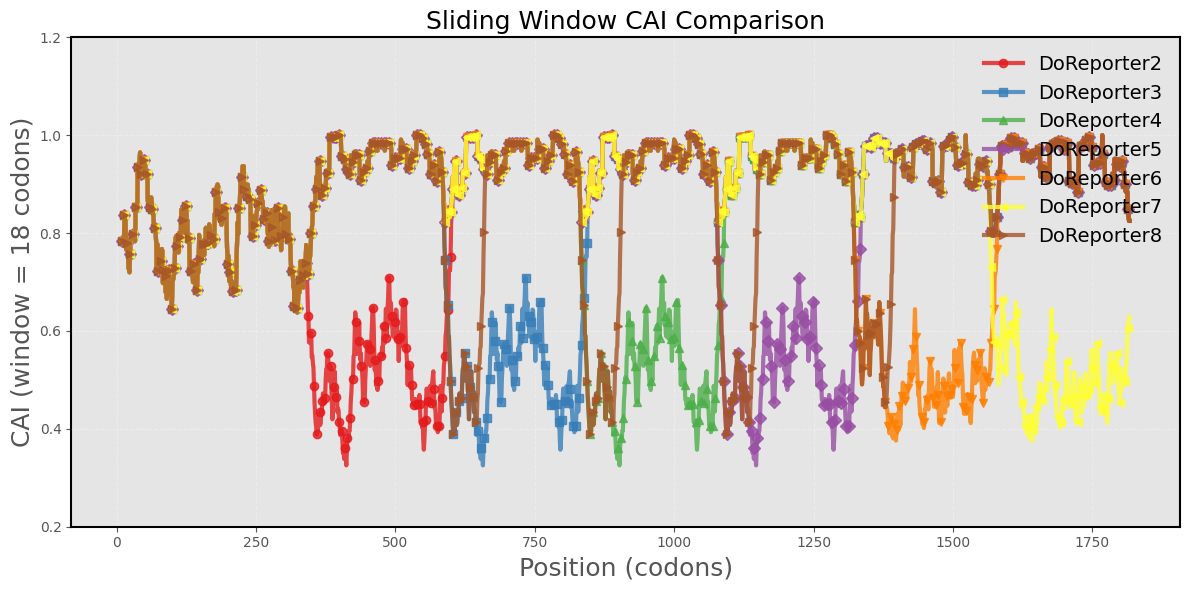

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Sliding Window CAI Comparison'}, xlabel='Position (codons)', ylabel='CAI (window = 18 codons)'>)

In [15]:
window_size =18
step_size=1

plot_sliding_window_cai(
    sequences=list_of_sequences,
    sequence_names=list_of_sequences_names,
    window_size=window_size,
    step=step_size,
    figsize=(12, 6),
    save_path='test.svg', 
    color_map = 'Set1',
    
)

## Synthesis Complexity Analysis

Before ordering gene synthesis, analyze the constructs for potential issues:
- Repetitive sequences
- Homopolymer runs
- Extreme GC content
- Hairpin structures


In [ ]:
# Compare synthesis complexity of all sequences
from tasep_models import compare_synthesis_complexity, suggest_synthesis_alternatives

compare_synthesis_complexity(list_of_sequences, list_of_sequences_names)


### Optimize Problematic Sequences

If any sequences show **MODERATE** or **DIFFICULT** complexity,
generate synthesis-friendly alternatives:


In [ ]:
# Example: Generate optimized alternatives for a problematic sequence
# Uncomment and modify for your specific sequence:

# result = suggest_synthesis_alternatives(
#     list_of_sequences[0],  # Replace with problematic sequence
#     name=list_of_sequences_names[0],
#     n_alternatives=3
# )
# 
# # Get recommended sequence
# optimized_seq = result['recommended']['sequence']


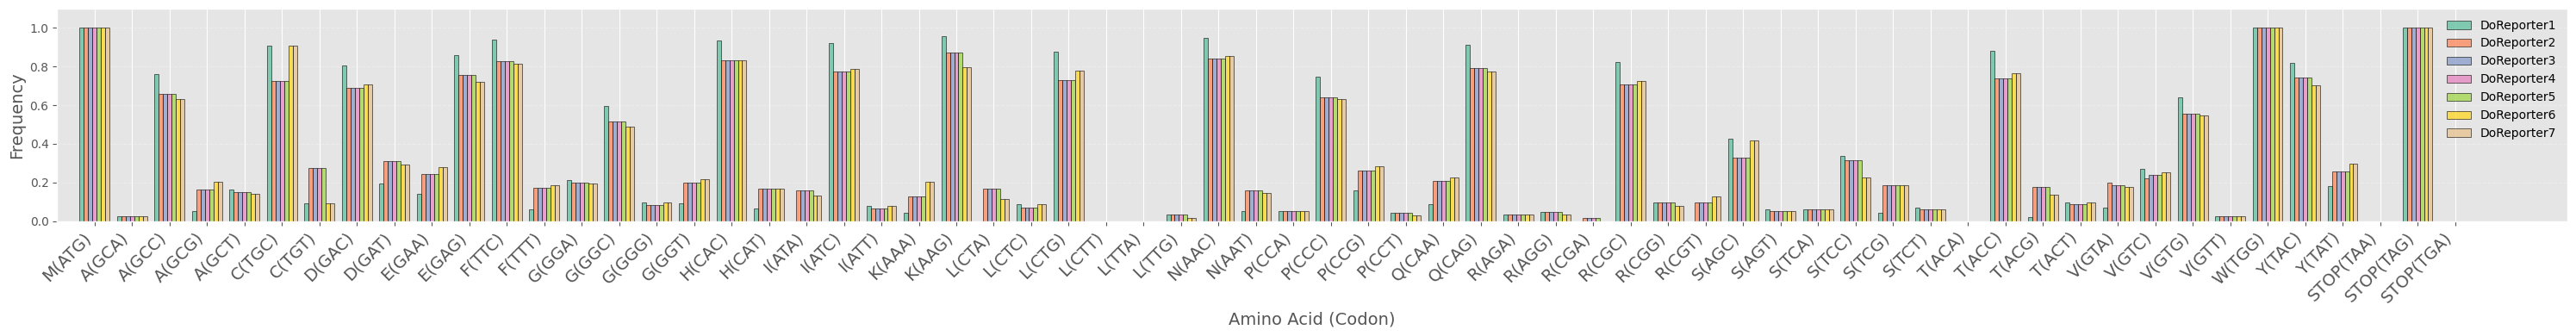

(<Figure size 3000x400 with 1 Axes>,
 <Axes: xlabel='Amino Acid (Codon)', ylabel='Frequency'>)

In [8]:
plot_codon_usage_grouped(
    sequences=list_of_sequences,
    sequence_names=list_of_sequences_names,
    x_label_type='aa_codon',
    figsize=(30, 4),
    color_map='Set2',
    include_stop_codons=True,
)

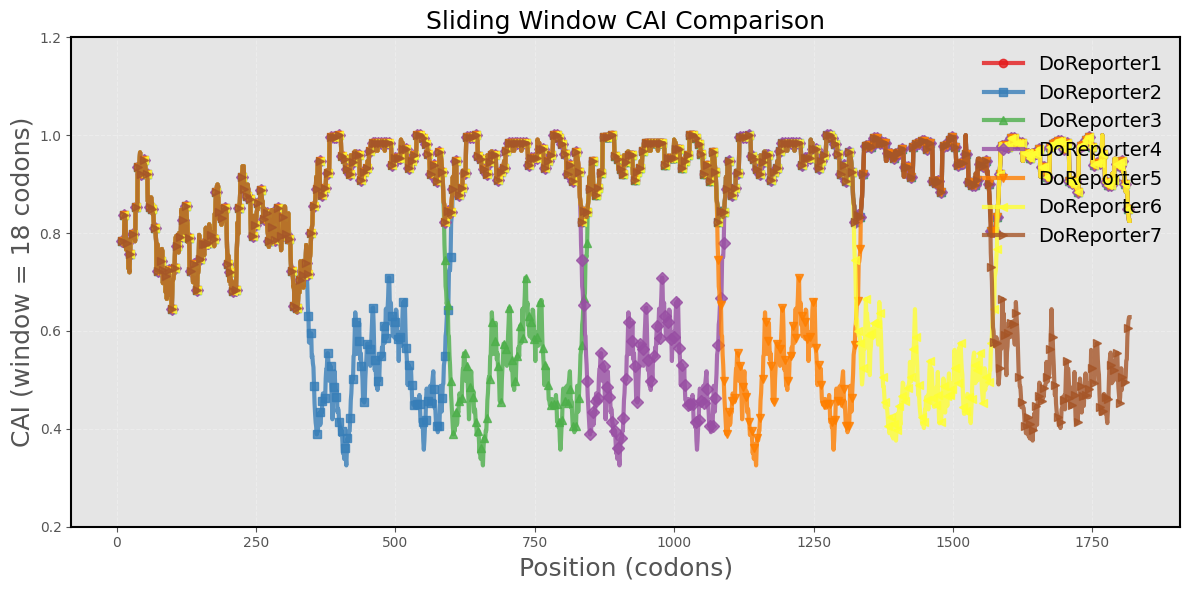

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt

# call your plot function as you already do
plot_sliding_window_cai(
    sequences=list_of_sequences,
    sequence_names=list_of_sequences_names,
    window_size=window_size,
    step=step_size,
    figsize=(12, 6),
    save_path=None,
    color_map='Set1'
)

# remove legend(s) safely
# remove legend(s)
fig = plt.gcf()
for ax in fig.axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()
    # remove text annotations added by ax.text/ax.annotate
    for txt in list(ax.texts):
        txt.remove()

In [10]:
import matplotlib.pyplot as plt

# call plot
plot_sliding_window_cai(...)

# remove legend(s)
fig = plt.gcf()
for ax in fig.axes:
    leg = ax.get_legend()
    if leg:
        leg.remove()
    # remove text annotations added by ax.text/ax.annotate
    for txt in list(ax.texts):
        txt.remove()

plt.show()